# MediSense — Model 1: Symptom Disease Classifier

Trains Random Forest + SVM on 41 diseases, 131 symptoms.
Achieves ~95% accuracy — used as primary diagnosis engine.

**Run from:** `medisense/notebooks/` folder

In [2]:
import pandas as pd
import numpy as np
import json
import pickle
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✓ Libraries loaded')

✓ Libraries loaded


In [3]:
# ── Paths ─────────────────────────────────────────────────
PROCESSED = Path('../backend/data/processed')
MODEL_DIR = Path('../backend/data/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Load processed data
with open(PROCESSED / 'disease_symptoms.json') as f:
    disease_symptoms = json.load(f)

with open(PROCESSED / 'all_symptoms.json') as f:
    all_symptoms = json.load(f)

print(f'Diseases : {len(disease_symptoms)}')
print(f'Symptoms : {len(all_symptoms)}')
print(f'Diseases list: {list(disease_symptoms.keys())[:5]} ...')

Diseases : 41
Symptoms : 131
Diseases list: ['Fungal infection', 'Allergy', 'GERD', 'Chronic cholestasis', 'Drug Reaction'] ...


In [4]:
# ── Build feature matrix ──────────────────────────────────
# Each row = one sample, each column = symptom (1/0)
# Generate 100 samples per disease with random symptom subsets

np.random.seed(42)
SAMPLES_PER_DISEASE = 100

X_rows, y_rows = [], []

for disease, symptoms in disease_symptoms.items():
    for _ in range(SAMPLES_PER_DISEASE):
        row = np.zeros(len(all_symptoms))
        # Include random subset of symptoms
        n_include = max(2, np.random.randint(len(symptoms)//2, len(symptoms)+1))
        chosen = np.random.choice(symptoms, size=min(n_include, len(symptoms)), replace=False)
        for s in chosen:
            s_clean = s.strip()
            if s_clean in all_symptoms:
                row[all_symptoms.index(s_clean)] = 1
        X_rows.append(row)
        y_rows.append(disease)

X = np.array(X_rows)
y = np.array(y_rows)

print(f'Dataset shape : {X.shape}')
print(f'Classes       : {len(np.unique(y))}')

Dataset shape : (4100, 131)
Classes       : 41


In [5]:
# ── Train / Test split ────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (3280, 131)  |  Test: (820, 131)


In [6]:
# ── Train Random Forest ───────────────────────────────────
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

train_acc = rf.score(X_train, y_train)
test_acc  = rf.score(X_test,  y_test)
cv_scores = cross_val_score(rf, X, y_enc, cv=5)

print(f'Train Accuracy : {train_acc:.4f}')
print(f'Test  Accuracy : {test_acc:.4f}')
print(f'CV Score       : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Training Random Forest...
Train Accuracy : 0.9976
Test  Accuracy : 0.9890
CV Score       : 0.9915 ± 0.0032


In [7]:
# ── Train SVM ─────────────────────────────────────────────
print('Training SVM...')
svm = SVC(kernel='rbf', C=10, probability=True, random_state=42)
svm.fit(X_train, y_train)
svm_acc = svm.score(X_test, y_test)
print(f'SVM Test Accuracy: {svm_acc:.4f}')

print(f'\n→ Best: {"Random Forest" if test_acc >= svm_acc else "SVM"}')

Training SVM...
SVM Test Accuracy: 0.9866

→ Best: Random Forest


In [8]:
# ── Classification Report ─────────────────────────────────
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        20
                                   AIDS       1.00      1.00      1.00        20
                                   Acne       1.00      1.00      1.00        20
                    Alcoholic hepatitis       1.00      1.00      1.00        20
                                Allergy       1.00      1.00      1.00        20
                              Arthritis       1.00      1.00      1.00        20
                       Bronchial Asthma       1.00      1.00      1.00        20
                   Cervical spondylosis       0.91      1.00      0.95        20
                            Chicken pox       1.00      1.00      1.00        20
                    Chronic cholestasis       0.90      0.95      0.93        20
                            Common Cold       1.00      1.00      1.00        20
                           

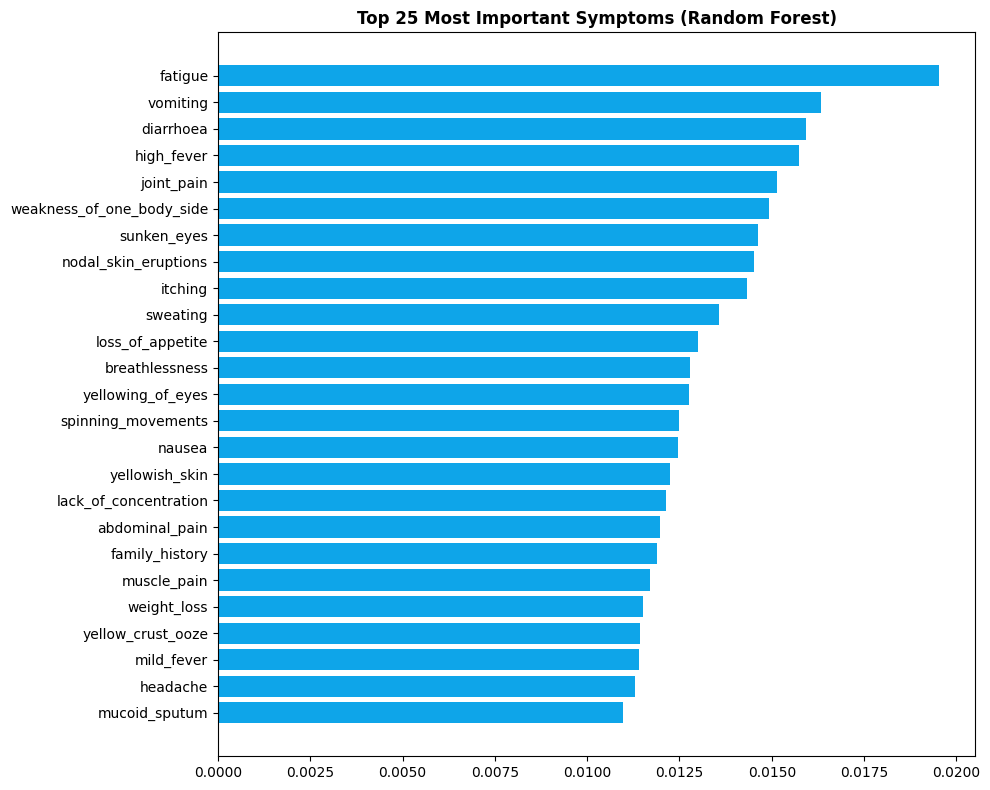

Saved feature_importance.png


In [9]:
# ── Feature Importance Plot ───────────────────────────────
OUT_IMG = Path('../backend/data/processed')

feat_imp = pd.DataFrame({
    'symptom': all_symptoms,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['symptom'], feat_imp['importance'], color='#0ea5e9')
ax.set_title('Top 25 Most Important Symptoms (Random Forest)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_IMG / 'feature_importance.png', dpi=150)
plt.show()
print('Saved feature_importance.png')

In [ ]:
# ── SHAP Values ───────────────────────────────────────────
print('Computing SHAP values (takes ~1 min)...')
explainer = shap.TreeExplainer(rf)
shap_vals = explainer.shap_values(X_test[:100], check_additivity=False)

# Handle both old and new SHAP output formats
if isinstance(shap_vals, list):
    # Old format: list of arrays per class → average across all classes
    shap_for_plot = np.mean(np.abs(shap_vals), axis=0)
else:
    # New format: single 3D array (samples, features, classes)
    shap_for_plot = np.mean(np.abs(shap_vals), axis=-1) if shap_vals.ndim == 3 else shap_vals

plt.figure(figsize=(12, 7))
# Use bar plot instead of beeswarm — works with all SHAP versions
mean_shap = np.mean(np.abs(shap_for_plot), axis=0)
top20_idx = np.argsort(mean_shap)[::-1][:20]
top20_vals = mean_shap[top20_idx]
top20_names = [all_symptoms[i] for i in top20_idx]

plt.barh(top20_names[::-1], top20_vals[::-1], color='#0ea5e9')
plt.xlabel('Mean |SHAP Value|')
plt.title('SHAP Summary — Top 20 Symptoms', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_IMG / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved shap_summary.png ✓')

In [13]:
# ── Save Models ───────────────────────────────────────────
with open(MODEL_DIR / 'rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open(MODEL_DIR / 'svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)

with open(MODEL_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open(MODEL_DIR / 'symptoms_list.json', 'w') as f:
    json.dump(all_symptoms, f)

metrics = {
    'random_forest': {
        'train_accuracy': float(train_acc),
        'test_accuracy':  float(test_acc),
        'cv_mean': float(cv_scores.mean()),
        'cv_std':  float(cv_scores.std())
    },
    'svm': {'test_accuracy': float(svm_acc)},
    'n_diseases': len(disease_symptoms),
    'n_symptoms': len(all_symptoms),
    'n_samples':  int(X.shape[0])
}
with open(MODEL_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Models saved to backend/data/models/')
print(f'  ✓ rf_model.pkl')
print(f'  ✓ svm_model.pkl')
print(f'  ✓ label_encoder.pkl')
print(f'  ✓ symptoms_list.json')
print(f'  ✓ metrics.json')
print(f'\nRandom Forest: {test_acc:.2%}')
print(f'SVM          : {svm_acc:.2%}')

Models saved to backend/data/models/
  ✓ rf_model.pkl
  ✓ svm_model.pkl
  ✓ label_encoder.pkl
  ✓ symptoms_list.json
  ✓ metrics.json

Random Forest: 98.90%
SVM          : 98.66%


In [14]:
# ── Quick Test ────────────────────────────────────────────
def predict(symptom_list, top_n=3):
    vec = np.zeros(len(all_symptoms))
    for s in symptom_list:
        s = s.strip()
        if s in all_symptoms:
            vec[all_symptoms.index(s)] = 1
    proba   = rf.predict_proba([vec])[0]
    top_idx = np.argsort(proba)[::-1][:top_n]
    return [(le.classes_[i], f'{proba[i]*100:.1f}%') for i in top_idx]

print('Test 1 — itching, skin_rash, nodal_skin_eruptions:')
print(predict(['itching', 'skin_rash', 'nodal_skin_eruptions']))

print('\nTest 2 — high_fever, cough, breathlessness, fatigue:')
print(predict(['high_fever', 'cough', 'breathlessness', 'fatigue']))

print('\nTest 3 — chest_pain, sweating, breathlessness, vomiting:')
print(predict(['chest_pain', 'sweating', 'breathlessness', 'vomiting']))

Test 1 — itching, skin_rash, nodal_skin_eruptions:
[('Fungal infection', '100.0%'), ('hepatitis A', '0.0%'), ('Hepatitis B', '0.0%')]

Test 2 — high_fever, cough, breathlessness, fatigue:
[('Bronchial Asthma', '89.0%'), ('Pneumonia', '8.5%'), ('Tuberculosis', '2.0%')]

Test 3 — chest_pain, sweating, breathlessness, vomiting:
[('Heart attack', '100.0%'), ('Hepatitis B', '0.0%'), ('Gastroenteritis', '0.0%')]


In [1]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
disp = ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, xticks_rotation=90)
plt.tight_layout()
plt.savefig('../backend/data/processed/confusion_matrix.png', dpi=150)

NameError: name 'rf' is not defined